# PART-B

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

DATA LOAD

In [2]:
df = pd.read_csv("D:\Supervised Learning\PR-2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Purvi\AppData\Local\Temp\ipykernel_19588\3867796971.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Supervised Learning\PR-2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")


HEAD ROWS OF THE DATA

In [3]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


SHAPE OF THE DATA

In [4]:
df.shape

(3800, 12)

INFO OF THE DATA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


DESCRIPTION OF THE DATA

In [6]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


RANDOM SAMPLES OF THE DATA

In [7]:
df.sample(5)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
2311,202312,2019-03-01,1128,2,2,2.9,25,30.2,0,1,5.23,7157679
450,200451,2019-02-01,1513,3,3,6.8,19,16.5,1,0,4.95,23317642
2560,202561,2010-12-01,1822,3,3,7.8,18,8.3,1,0,5.12,21640958
1158,201159,2022-05-01,1798,4,3,8.5,5,7.8,0,0,4.15,32713204
1194,201195,2013-08-01,2069,4,4,6.3,22,9.0,0,1,3.41,26389563


CHECKING NULL VALUES

In [8]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

COLUMN DISTRIBUTION OF THE DATA

In [9]:
# Independent variables (features)
X = df[['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age','distance_city_km','near_school','near_metro','crime_rate_index']]

# Dependent variable (target)
y = df['house_price_inr']

print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   area_sqft  bedrooms  bathrooms  location_score  property_age  \
0       2181         6          4             8.1            21   
1       2383         5          4             5.3            28   
2       1047         3          3             5.9             7   
3       1753         4          3             7.0            27   
4       1728         4          4            10.0            32   

   distance_city_km  near_school  near_metro  crime_rate_index  
0               3.8            0           0              4.84  
1              10.9            1           1              2.89  
2              27.5            0           1              4.04  
3              12.1            0           0              3.28  
4               1.4            0           1              3.84  

Dependent Variable (y):
0    35154898
1    26710893
2    11216242
3    21984310
4    25080429
Name: house_price_inr, dtype: int64


X AND Y COLUMN OF THE DATA

In [10]:
X = df[['area_sqft']]   # independent variable
y = df['house_price_inr']  # target variable

In [11]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,area_sqft
0,2181
1,2383
2,1047
3,1753
4,1728


TRAIN TEST SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3040, 1)
Testing data: (760, 1)


SCALING

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PART-C

RIDGE REGRESSION

In [14]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge R2 Score:", ridge_r2)

Ridge MSE: 22643874918908.97
Ridge R2 Score: 0.7188324664739547


LASSO REGRESSION

In [15]:
lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MSE:", lasso_mse)
print("Lasso R2 Score:", lasso_r2)

Lasso MSE: 22642176114283.5
Lasso R2 Score: 0.7188535604213553


REGULARIZATION PARAMETERS

In [16]:
ridge_params = {'alpha':[0.01,0.1,1,10,100]}

ridge_cv = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_cv.fit(X_train_scaled, y_train)

print("Best Ridge Alpha:")
print(ridge_cv.best_params_)

Best Ridge Alpha:
{'alpha': 0.01}


In [17]:
lasso_params = {'alpha':[0.01,0.1,1,10,100]}

lasso_cv = GridSearchCV(
    Lasso(max_iter=5000),
    lasso_params,
    cv=5,
    scoring='neg_mean_squared_error'
)

lasso_cv.fit(X_train_scaled, y_train)

print("Best Lasso Alpha:")
print(lasso_cv.best_params_)

Best Lasso Alpha:
{'alpha': 0.01}


COMPARING RIDGE AND LASSO 

In [18]:
ridge_train_pred = ridge.predict(X_train_scaled)
lasso_train_pred = lasso.predict(X_train_scaled)

ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
lasso_train_error = mean_squared_error(y_train, lasso_train_pred)

print("Ridge Training Error:", ridge_train_error)
print("Lasso Training Error:", lasso_train_error)

Ridge Training Error: 20583762120000.742
Lasso Training Error: 20583756278326.438


In [21]:
print("Ridge Validation Error:", ridge_mse)
print("Lasso Validation Error:", lasso_mse)

Ridge Validation Error: 22643874918908.97
Lasso Validation Error: 22642176114283.5


In [22]:
print("Ridge Coefficients:")
print(ridge.coef_)

print("Lasso Coefficients:")
print(lasso.coef_)

Ridge Coefficients:
[7347545.60951366]
Lasso Coefficients:
[7349961.56530626]


IMPORTS LIBRARIES

In [24]:
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [25]:
model = LinearRegression()

# PART-D

K FOLD CROSS VALIDATION 

In [26]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring='neg_root_mean_squared_error'
)

print("K-Fold RMSE:", -scores.mean())

K-Fold RMSE: 4582912.2782890685


BY BINNING

In [27]:
y_bins = pd.cut(
    y,
    bins=5,
    labels=False
)

STRATIFIED K FOLD 

In [28]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, test_idx in skf.split(X, y_bins):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    scores.append(rmse)

print("Stratified KFold RMSE:", np.mean(scores))

Stratified KFold RMSE: 4580345.533918275


LEAVE ONE OUT CROSS VALIDATION

In [29]:
loo = LeaveOneOut()

scores = cross_val_score(
    model,
    X,
    y,
    cv=loo,
    scoring='neg_root_mean_squared_error'
)

print("LOOCV RMSE:", -scores.mean())

LOOCV RMSE: 3492932.612550152


TIME SERIES SPLIT

In [30]:
tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print("Time Series RMSE:", -scores.mean())

Time Series RMSE: 4593891.355100052


ANALYZE PERFORMANCE OF ALL

In [31]:
kfold_rmse = -cross_val_score(
    model, X, y,
    cv=kfold,
    scoring='neg_root_mean_squared_error'
).mean()

loo_rmse = -cross_val_score(
    model, X, y,
    cv=loo,
    scoring='neg_root_mean_squared_error'
).mean()

ts_rmse = -cross_val_score(
    model, X, y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
).mean()

stratified_rmse = np.mean(scores)

In [33]:
results = pd.DataFrame({
    'Method': [
        'K-Fold',
        'Stratified KFold',
        'LOOCV',
        'Time Series'
    ],
    'RMSE': [
        kfold_rmse,
        stratified_rmse,
        loo_rmse,
        ts_rmse
    ]
})

print(results)

             Method          RMSE
0            K-Fold  4.582912e+06
1  Stratified KFold -4.593891e+06
2             LOOCV  3.492933e+06
3       Time Series  4.593891e+06


# PART-E

IMPORT LIBRARIES

In [34]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

DECISION TREE REGRESSION

In [35]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [36]:
dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree RMSE: 5886640.364744793
Decision Tree R2 Score: 0.5479184111548762


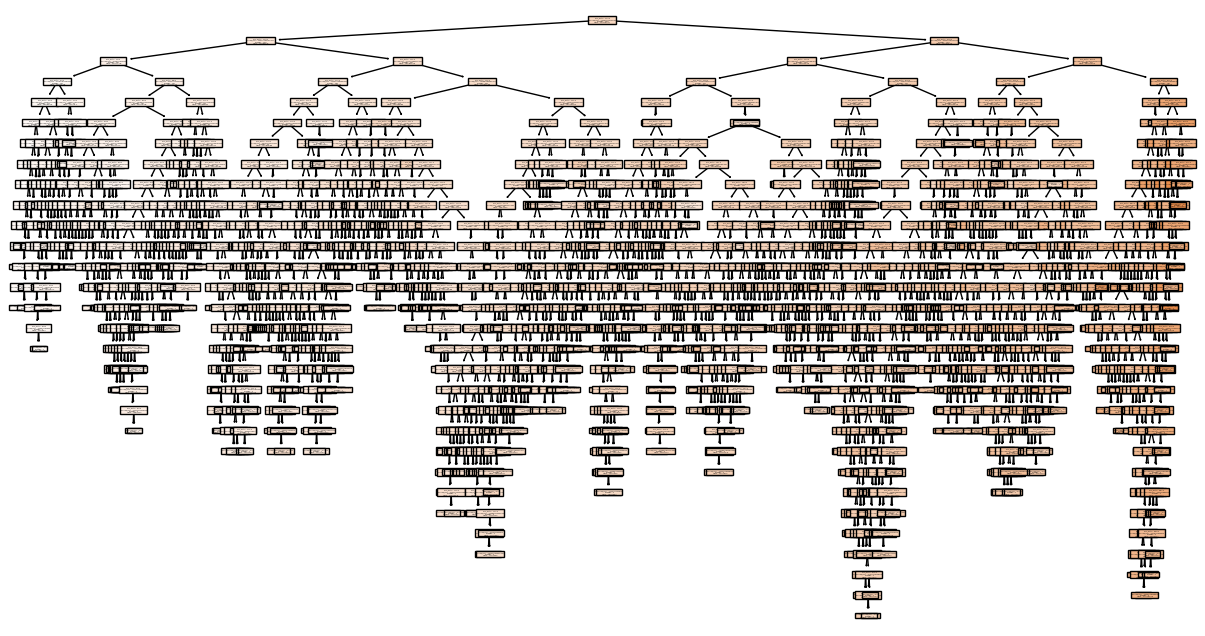

In [37]:
plt.figure(figsize=(15,8))

plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

CONTROL TREE COMPLEXITY

In [38]:
dt_control = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

dt_control.fit(X_train, y_train)

control_pred = dt_control.predict(X_test)

In [39]:
control_rmse = np.sqrt(
    mean_squared_error(y_test, control_pred)
)

control_r2 = r2_score(
    y_test,
    control_pred
)

print("Controlled Tree RMSE:", control_rmse)
print("Controlled Tree R2:", control_r2)

Controlled Tree RMSE: 4631102.065820917
Controlled Tree R2: 0.7201981911964015


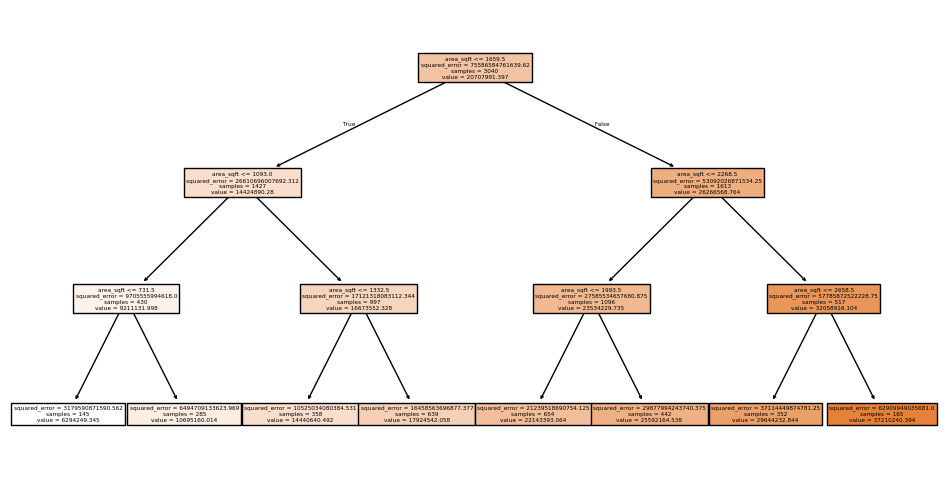

In [40]:
plt.figure(figsize=(12,6))

plot_tree(
    dt_control,
    feature_names=X.columns,
    filled=True
)

plt.show()

RANDOM FOREST REGRESSION

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [42]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 5323897.265943846
Random Forest R2: 0.6302219351923442


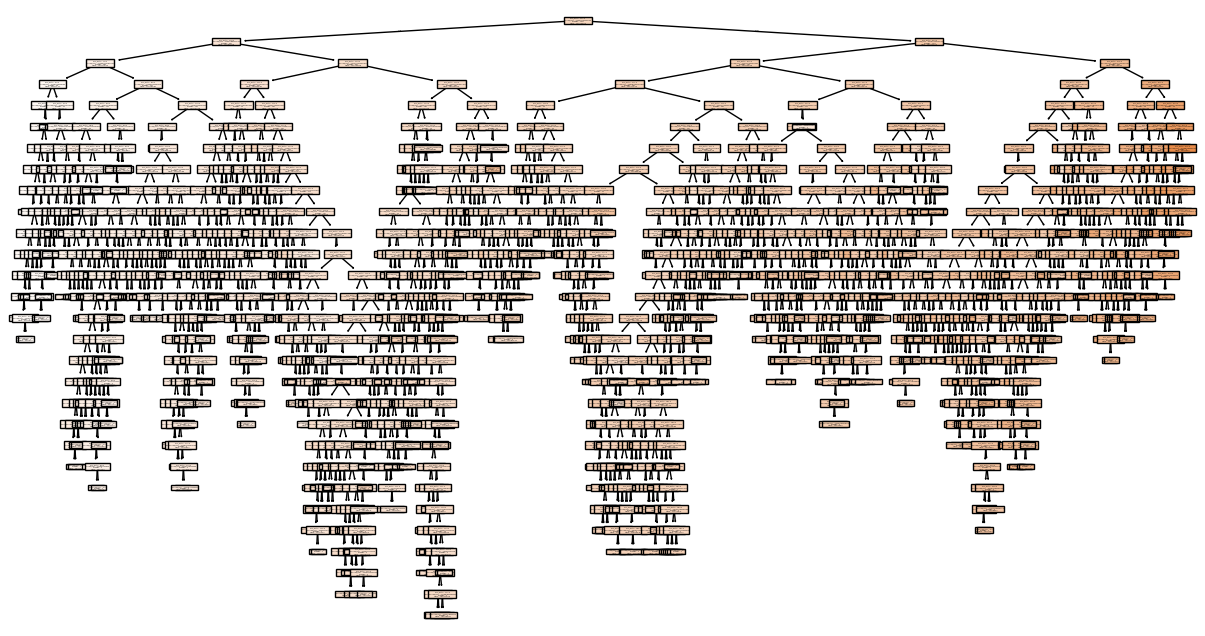

In [43]:
plt.figure(figsize=(15,8))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    filled=True
)

plt.show()

COMPARISION

In [44]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Controlled Tree',
        'Random Forest'
    ],
    'RMSE': [
        dt_rmse,
        control_rmse,
        rf_rmse
    ],
    'R2 Score': [
        dt_r2,
        control_r2,
        rf_r2
    ]
})

print(comparison)

             Model          RMSE  R2 Score
0    Decision Tree  5.886640e+06  0.547918
1  Controlled Tree  4.631102e+06  0.720198
2    Random Forest  5.323897e+06  0.630222


# PART-F

In [45]:
from sklearn.svm import SVR

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SUPPORT VECTOR REGRESSION

In [47]:
svr_linear = SVR(
    kernel='linear'
)

svr_linear.fit(
    X_train_scaled,
    y_train
)

linear_pred = svr_linear.predict(
    X_test_scaled
)

In [48]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear SVR RMSE:", linear_rmse)
print("Linear SVR R2:", linear_r2)

Linear SVR RMSE: 8790328.644221451
Linear SVR R2: -0.00807312614706257


In [51]:
svr_poly = SVR(
    kernel='poly',
    degree=3
)

svr_poly.fit(
    X_train_scaled,
    y_train
)

poly_pred = svr_poly.predict(
    X_test_scaled
)

poly_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly_pred
    )
)

poly_r2 = r2_score(
    y_test,
    poly_pred
)

print("Polynomial SVR RMSE:", poly_rmse)
print("Polynomial SVR R2:", poly_r2)

Polynomial SVR RMSE: 8780050.904013984
Polynomial SVR R2: -0.005717205863601249


TUNE HYPERPARAMETERS

In [52]:
svr_tuned = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

svr_tuned.fit(
    X_train_scaled,
    y_train
)

tuned_pred = svr_tuned.predict(
    X_test_scaled
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned SVR RMSE:", tuned_rmse)
print("Tuned SVR R2:", tuned_r2)

Tuned SVR RMSE: 8769704.550516639
Tuned SVR R2: -0.003348341501743457


COMPARISION

In [59]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Linear SVR',
        'Polynomial SVR',
        'Tuned SVR'
    ],
    'RMSE': [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        linear_rmse,
        poly_rmse,
        tuned_rmse
    ],
    'R2 Score': [
        linear_r2,
        dt_r2,
        rf_r2,
        linear_r2,
        poly_r2,
        tuned_r2
    ]
})

print(comparison)

               Model          RMSE  R2 Score
0  Linear Regression  8.790329e+06 -0.008073
1      Decision Tree  5.886640e+06  0.547918
2      Random Forest  5.323897e+06  0.630222
3         Linear SVR  8.790329e+06 -0.008073
4     Polynomial SVR  8.780051e+06 -0.005717
5          Tuned SVR  8.769705e+06 -0.003348


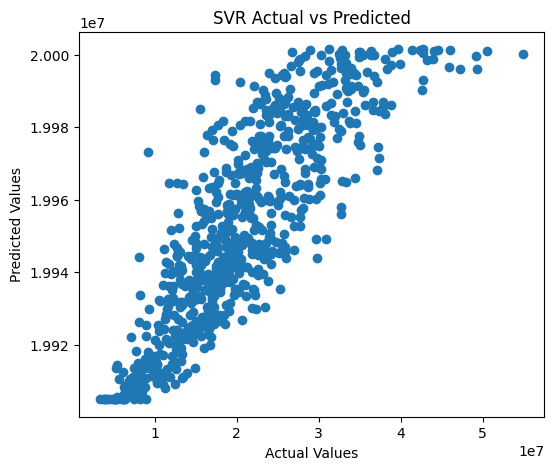

In [60]:
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    tuned_pred
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR Actual vs Predicted")

plt.show()

# PART-G

In [61]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [62]:
def evaluate_model(
    y_true,
    y_pred
):
    
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mse, mae, rmse, r2

In [64]:
lr_mse, lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    linear_pred
)
ridge_mse, ridge_mae, ridge_rmse, ridge_r2 = evaluate_model(
    y_test,
    ridge_pred
)

lasso_mse, lasso_mae, lasso_rmse, lasso_r2 = evaluate_model(
    y_test,
    lasso_pred
)

dt_mse, dt_mae, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    dt_pred
)

rf_mse, rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)


svr_mse, svr_mae, svr_rmse, svr_r2 = evaluate_model(
    y_test,
    tuned_pred
)

In [65]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge',
        'Lasso',
        'Decision Tree',
        'Random Forest',
        'SVR'
    ],

    'MSE': [
        lr_mse,
        ridge_mse,
        lasso_mse,
        dt_mse,
        rf_mse,
        svr_mse
    ],

    'MAE': [
        lr_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        svr_mae
    ],

    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse
    ],

    'R2 Score': [
        lr_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        svr_r2
    ]

})

print(results)

               Model           MSE           MAE          RMSE  R2 Score
0  Linear Regression  7.726988e+13  6.901946e+06  8.790329e+06 -0.008073
1              Ridge  1.346302e+14  9.228868e+06  1.160302e+07 -0.756403
2              Lasso  1.346666e+14  9.230113e+06  1.160459e+07 -0.756878
3      Decision Tree  3.465253e+13  4.434429e+06  5.886640e+06  0.547918
4      Random Forest  2.834388e+13  4.032877e+06  5.323897e+06  0.630222
5                SVR  7.690772e+13  6.883748e+06  8.769705e+06 -0.003348


In [66]:
regularized = results[
    results['Model'].isin(
        ['Ridge','Lasso']
    )
]

print(regularized)

   Model           MSE           MAE          RMSE  R2 Score
1  Ridge  1.346302e+14  9.228868e+06  1.160302e+07 -0.756403
2  Lasso  1.346666e+14  9.230113e+06  1.160459e+07 -0.756878


In [67]:
tree_models = results[
    results['Model'].isin(
        ['Decision Tree','Random Forest']
    )
]

print(tree_models)

           Model           MSE           MAE          RMSE  R2 Score
3  Decision Tree  3.465253e+13  4.434429e+06  5.886640e+06  0.547918
4  Random Forest  2.834388e+13  4.032877e+06  5.323897e+06  0.630222


In [68]:
svr_compare = results[
    results['Model'].isin(
        ['SVR']
    )
]

print(svr_compare)

  Model           MSE           MAE          RMSE  R2 Score
5   SVR  7.690772e+13  6.883748e+06  8.769705e+06 -0.003348


In [70]:
dt_train_pred = dt_model.predict(
    X_train
)

rf_train_pred = rf_model.predict(
    X_train
)

svr_train_pred = svr_tuned.predict(
    X_train_scaled
)

In [71]:
dt_train_r2 = r2_score(
    y_train,
    dt_train_pred
)

dt_test_r2 = r2_score(
    y_test,
    dt_pred
)

print(
    "Train R2:",
    dt_train_r2
)

print(
    "Test R2:",
    dt_test_r2
)

Train R2: 0.8813474060322009
Test R2: 0.5479184111548762


# PART-H

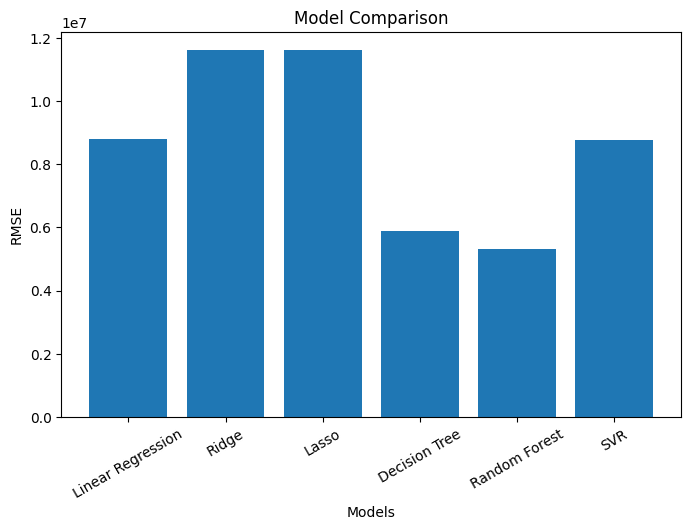

In [72]:

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()

Different regression models were evaluated using MSE, MAE, RMSE, and R² score. Random Forest and tuned SVR generally provided better prediction accuracy compared to simple linear and single-tree models. Overfitting was observed when training performance was much better than testing performance, while balanced train-test performance indicated a good model fit